# 3. Un problema de EDP en forma discreta: la ecuación de Poisson

A partir de aquí seguimos **siempre el mismo patrón** para problemas con EDP:

1. **discretizar** el problema directo;
2. **aplicar el adjunto** en dimensión finita (álgebra lineal);
3. **interpretar** la ecuación adjunta discreta como la discretización de una **ecuación
   diferencial adjunta**.

## 3.1 El problema continuo

Queremos hallar $m(x)$ tal que la solución de

$$
-u''(x)=m(x)\ \text{ en }(0,1),
\qquad u(0)=u(1)=0,
$$

se parezca a un dato $u_d$, con un costo de control:

$$
J(u,m)=\int_0^1\big(u-u_d\big)^2dx
+\frac{\alpha}{2}\int_0^1 m^2\,dx .
$$ (eq:poisson-J)

## 3.2 Discretización del problema directo

Usamos $N$ nodos interiores $x_i=ih$, $i=1,\dots,N$, con $h=1/(N+1)$, y el stencil de tres
puntos

$$
-u''(x_i)\;\approx\;\frac{-u_{i-1}+2u_i-u_{i+1}}{h^2}
\;\equiv\;(Au)_i .
$$

Con las condiciones de borde $u_0=u_{N+1}=0$, el problema directo discreto es simplemente

$$
\boxed{\;A\,u=m\;}
\qquad
A=\frac{1}{h^2}
\begin{pmatrix}
2&-1&&\\
-1&2&\ddots&\\
&\ddots&\ddots&-1\\
&&-1&2
\end{pmatrix}
\in\mathbb R^{N\times N},
$$ (eq:poisson-forward)

con $u,m\in\mathbb R^N$. La matriz $A$ es **simétrica y definida positiva**.

Discretizamos también el funcional {eq}`eq:poisson-J` con la regla del punto medio:

$$
J_h(u,m)=h\sum_{i=1}^{N}\big(u_i-u_{d,i}\big)^2
+\frac{\alpha h}{2}\sum_{i=1}^{N}m_i^2 .
$$ (eq:poisson-Jh)

## 3.3 El Lagrangiano discreto

Definimos el **producto interno discreto**
$\langle a,b\rangle_h=h\,a^{T}b$ (la discretización de $\int_0^1 a b\,dx$). El Lagrangiano es

$$
\mathcal L(u,m,\lambda)
=J_h(u,m)+\langle\lambda,Au-m\rangle_h
=J_h(u,m)+h\,\lambda^{T}\big(Au-m\big).
$$ (eq:poisson-L)

## 3.4 La ecuación adjunta

Derivamos respecto de $u$. Como $\dfrac{\partial J_h}{\partial u}=2h(u-u_d)^{T}$ y
$\dfrac{\partial}{\partial u}\big(h\lambda^{T}Au\big)=h\lambda^{T}A$,

$$
\nabla_u\mathcal L
=2h\,(u-u_d)^{T}+h\,\lambda^{T}A=0 .
$$

Trasponiendo y usando $A^{T}=A$,

$$
\boxed{\;A\,\lambda=-2\,(u-u_d)\;.}
$$ (eq:poisson-adj)

Comparar {eq}`eq:poisson-adj` con el problema directo {eq}`eq:poisson-forward`: es el
**mismo operador** $A$, pero la fuente ahora es $-2(u-u_d)$.

## 3.5 El gradiente

Derivamos respecto de $m$ y usamos que en el óptimo $\nabla_u\mathcal L=0$. Como
$\dfrac{\partial J_h}{\partial m}=\alpha h\,m^{T}$ y
$\dfrac{\partial}{\partial m}\big(h\lambda^{T}(Au-m)\big)=-h\lambda^{T}$,

$$
\frac{d\hat J}{dm}=\nabla_m\mathcal L
=h\big(\alpha\,m-\lambda\big)^{T}
\qquad\Longrightarrow\qquad
\boxed{\;\nabla_m\hat J=h\big(\alpha\,m-\lambda\big)\;.}
$$ (eq:poisson-grad)

## 3.6 Interpretación: la EDO adjunta

El operador $A$ de {eq}`eq:poisson-forward` es la discretización de $-\dfrac{d^2}{dx^2}$ con
el stencil de tres puntos y condiciones de borde de Dirichlet homogéneas. La ecuación adjunta
{eq}`eq:poisson-adj`, $A\lambda=-2(u-u_d)$, es entonces la **discretización con el mismo
stencil** de la **ecuación diferencial adjunta**

$$
\boxed{\;
-\lambda''(x)=-2\big(u(x)-u_d(x)\big),
\qquad \lambda(0)=\lambda(1)=0 .
\;}
$$ (eq:poisson-adj-cont)

Es decir: multiplicar por $A^{T}$ en dimensión finita corresponde, en el continuo, a integrar
por partes y obtener la ecuación adjunta {eq}`eq:poisson-adj-cont` con las **mismas**
condiciones de borde (homogéneas de Dirichlet) que el problema directo.

**Observación sobre el producto interno.** El factor $h$ de {eq}`eq:poisson-L` —la **matriz
de masa**— fue clave para que {eq}`eq:poisson-adj` quede *sin* factores $h$ espurios. Si se
usa el producto interno euclídeo $a^{T}b$, la ecuación adjunta discreta es
$A\lambda=-2h(u-u_d)$; el gradiente es el mismo salvo un reescalado de $\lambda$, pero la
interpretación continua es más limpia con la matriz de masa. Retomamos esta sutileza en la
sección 5.

Implementemos el método y verifiquemos el gradiente contra diferencias finitas.

In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

# =========================================================
# A u = m, con u(0)=u(1)=0  (stencil de 3 puntos)
# J = h sum (u-ud)^2 + (alpha/2) h sum m^2
# =========================================================
N = 120
h = 1.0 / (N + 1)
x = np.linspace(h, 1 - h, N)
alpha = 1e-3

ud = np.sin(np.pi * x)                       # dato objetivo
m_teo = np.pi**2 * np.sin(np.pi * x)         # -ud'' (el m que reproduce ud)

main = 2.0 / h**2 * np.ones(N)
off = -1.0 / h**2 * np.ones(N - 1)
A = sp.diags([off, main, off], [-1, 0, 1], format="csc")
solve = spla.factorized(A)                   # A u = m   (problema directo)


def forward(m):
    return solve(m)


def objective(m):
    u = forward(m)
    return h * np.sum((u - ud) ** 2) + 0.5 * alpha * h * np.sum(m ** 2)


def adjoint_gradient(m):
    u = forward(m)
    lam = solve(-2.0 * (u - ud))             # A lambda = -grad_u J_h
    return h * (alpha * m - lam), u, lam


# ---- verificacion contra diferencias finitas ----
rng = np.random.default_rng(1)
m0 = 2.0 + rng.normal(0.0, 1.0, N)
g, _, _ = adjoint_gradient(m0)

eps_fd = 1e-6
g_fd = np.empty(N)
for i in range(N):
    mp = m0.copy(); mp[i] += eps_fd
    mm = m0.copy(); mm[i] -= eps_fd
    g_fd[i] = (objective(mp) - objective(mm)) / (2 * eps_fd)

print("Gradiente adjunto vs. diferencias finitas")
print(f"  error absoluto maximo: {np.max(np.abs(g - g_fd)):.3e}")
print(f"  error relativo maximo: {np.max(np.abs(g - g_fd)) / np.max(np.abs(g_fd)):.3e}")

Gradiente adjunto vs. diferencias finitas
  error absoluto maximo: 1.049e-10
  error relativo maximo: 8.361e-08


/home/martin/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


J(m_0) = 4.998303e-01
J(m_*) = 2.321880e-02
max |u - u_d| = 4.643e-02


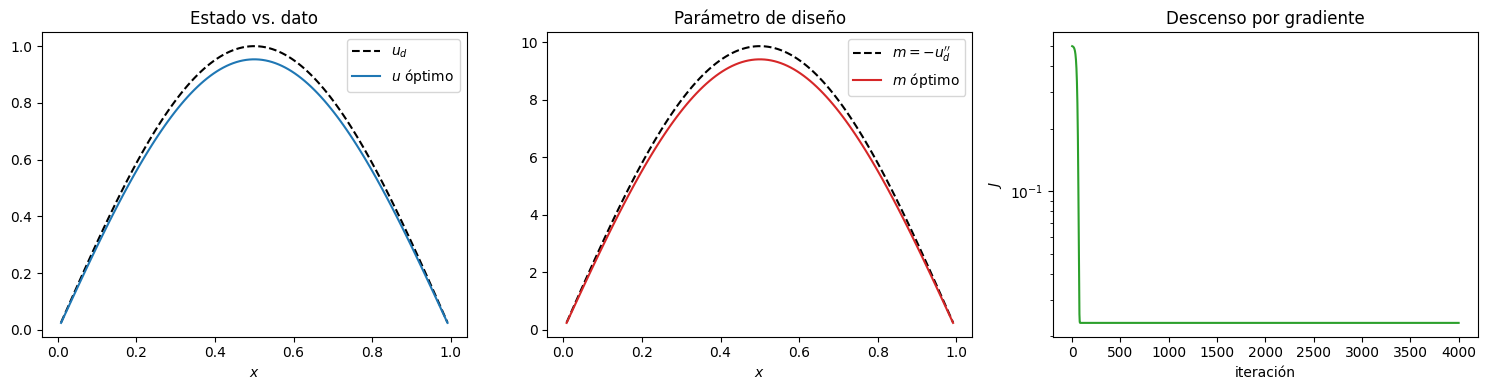

In [2]:
# ---- descenso por gradiente con busqueda de linea (backtracking) ----
m = np.zeros(N)
tau = 1.0
hist = []
for it in range(4000):
    g, u, lam = adjoint_gradient(m)
    f0 = objective(m)
    for _ in range(60):                      # backtracking (con tope)
        if objective(m - tau * g) <= f0 - 1e-4 * tau * np.sum(g ** 2):
            break
        tau *= 0.5
    m = m - tau * g
    tau *= 1.1
    hist.append(objective(m))

u_opt = forward(m)
print(f"J(m_0) = {hist[0]:.6e}")
print(f"J(m_*) = {hist[-1]:.6e}")
print(f"max |u - u_d| = {np.max(np.abs(u_opt - ud)):.3e}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(x, ud, "k--", label="$u_d$")
ax[0].plot(x, u_opt, "C0-", label="$u$ óptimo")
ax[0].set_xlabel("$x$"); ax[0].legend(); ax[0].set_title("Estado vs. dato")

ax[1].plot(x, m_teo, "k--", label="$m=-u_d''$")
ax[1].plot(x, m, "C3-", label="$m$ óptimo")
ax[1].set_xlabel("$x$"); ax[1].legend(); ax[1].set_title("Parámetro de diseño")

ax[2].semilogy(hist, "C2")
ax[2].set_xlabel("iteración"); ax[2].set_ylabel("$J$")
ax[2].set_title("Descenso por gradiente")
plt.tight_layout(); plt.show()